# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain
from trefftz.dg.materials import Dielectric
R = 1.
r = 0.2


lc = 2.

eps_r = 4.

material = Dielectric(relative_permittivity=eps_r)


mesh = AnularDomain(R=R, r=r, scatterer_material = material, verbosity=0, Lc=lc, lc=lc)


In [2]:
from trefftz.dg.parameters import Elementwise
import numpy as np 

Regions = mesh.regions

refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1.,
                                      Regions.OMEGA: np.sqrt(material.eps_r)})


In [3]:
mesh.n_triangles

130

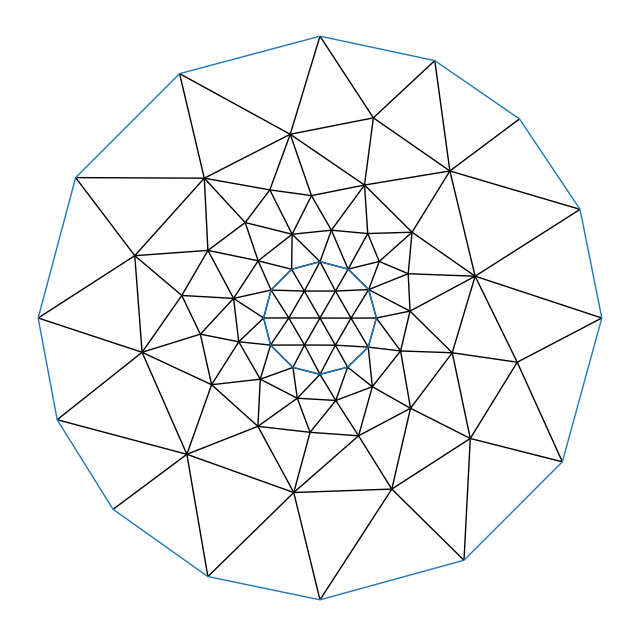

In [4]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

Text(0.5, 1.0, '$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

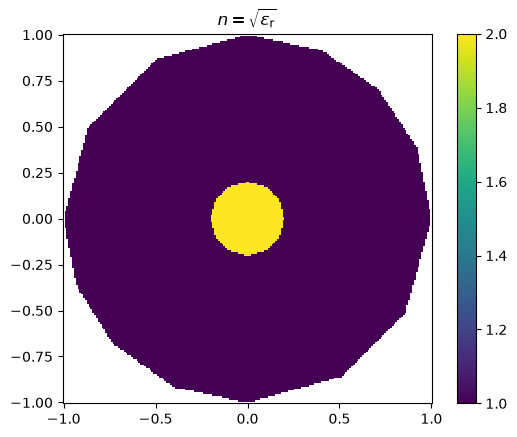

In [5]:
import matplotlib.pyplot as plt
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = refractive_index(X, Y)

plt.pcolormesh(X, Y, Z)
plt.axis('square')
plt.colorbar()
plt.title('$n=\\sqrt{\\varepsilon_\\mathrm{r}}$')

In [6]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [7]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)


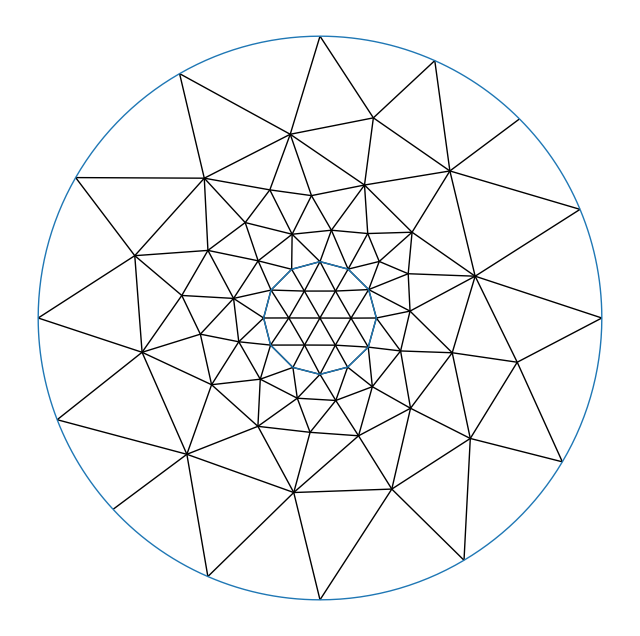

In [8]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [9]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [10]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=1.)
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}
# boundary_conditions = {Regions.SIGMA: DirichletBC(data=data),}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [11]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [12]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [13]:
# from trefftz.dg.assemblers import SerialNumerics
# NtD_modes = 15
# a = 0.5
# b = 0.5
# d2 = 0.5
# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

In [14]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 9
a = 0.5
b = 0.5
d2 = 0.5
numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [15]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
Ntheta = 18
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [16]:
basis.N_DOF

2340

In [17]:
# from trefftz.dg.assemblers import SerialAssembler

# assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [18]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [19]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [20]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 14.94edge/s]


region: d_Omega


Interior: 100%|██████████| 188/188 [00:00<00:00, 1070.69edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [00:43<00:00,  3.10s/edge]


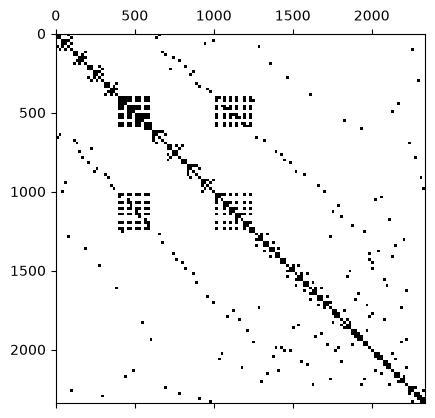

In [21]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [23]:
b = P.assemble_RHS()

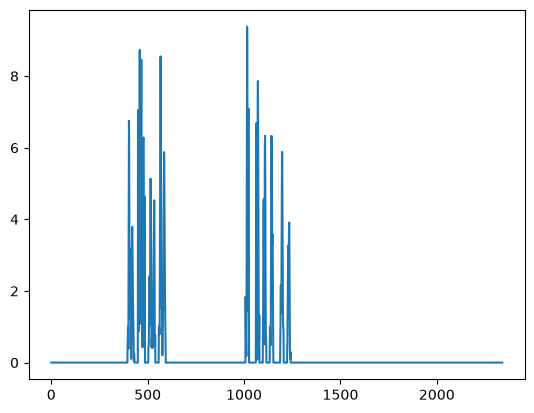

In [24]:
import numpy as np 
plt.plot(np.abs(b))

In [25]:
P.solve()

In [26]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 2.34883676e+06+5.39953195e+05j, -1.32597962e+06-1.66239199e+06j,
         1.32755296e+05+1.72165149e+06j, ...,
        -5.09952275e+05+2.53553304e+06j,  1.44934535e+06-2.18059509e+06j,
        -2.33537101e+06+1.06731874e+06j],
       [-4.23214524e+05-2.36990657e+05j,  6.61051703e+04+4.76726562e+05j,
         3.30801647e+05-3.44401027e+05j, ...,
         1.19541075e+05-4.82492009e+05j, -2.83499206e+05+4.03641262e+05j,
         4.64223253e+05-1.53874385e+05j],
       [ 6.38671593e+05-1.01028254e+06j, -8.64716387e+05+5.17734165e+05j,
         7.47068692e+05-1.95365488e+05j, ...,
         1.00432417e+06+4.12759734e+05j, -7.21349200e+05-1.03247636e+06j,
         1.05972255e+04+1.29150204e+06j],
       ...,
       [ 1.11253122e+04+2.83725458e+04j, -2.02100903e+04-2.32787933e+04j,
         2.63079428e+04+1.63770715e+04j, ...,
         1.36818248e+04-2.52973920e+04j, -7.85924479e+03+2.83073329e+04j,
        -9.38126558e+02-2.99587604e+04j],
       [ 2.03011408e+04-1.10644153e+04j, -1.

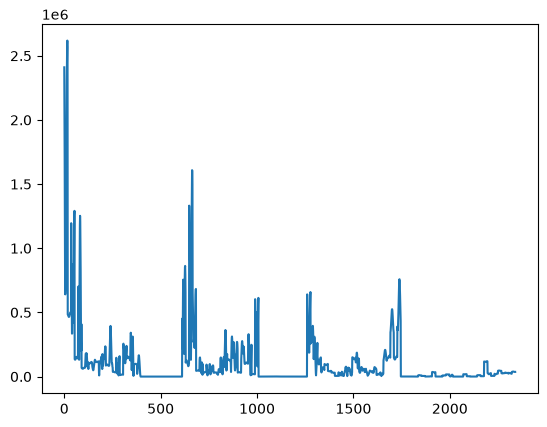

In [31]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [32]:
import numpy as np
# N = 200
# # rs = np.linspace(r, R, N)
# rs = np.linspace(0, R, N)

# theta = np.linspace(0, 2*np.pi, N)
# Rs, Theta = np.meshgrid(rs, theta)
# X = Rs*np.cos(Theta)
# Y = Rs*np.sin(Theta)
# x = X.ravel()
# y = Y.ravel() 
# z = P.u_h(x, y)

In [33]:
import matplotlib.pyplot as plt
# plt.scatter(x,y,c=np.real(z),cmap="viridis")
# plt.axis("square")

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

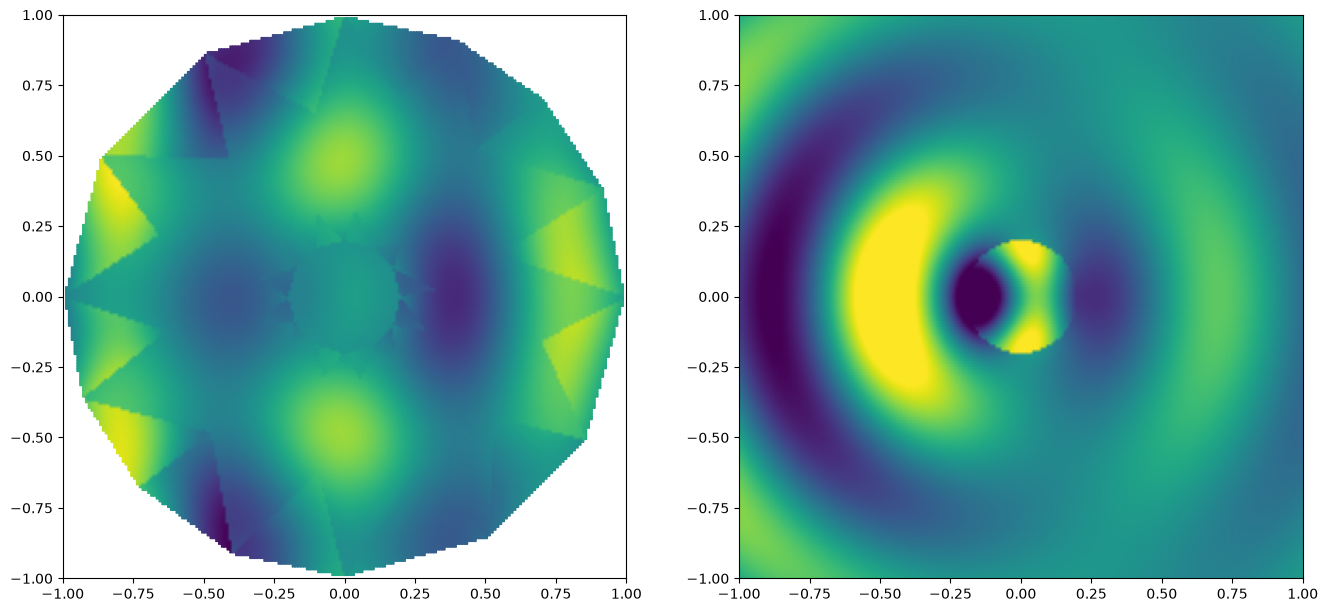

In [34]:
import matplotlib.pyplot as plt
from cases.open_space.exact import nf_diel_cylinder_plane_wave
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

Z = P.u_h(X, Y)

Z_exact = nf_diel_cylinder_plane_wave(X, Y, k, theta_inc=np.pi, eps_r=eps_r, c=np.array([0., 0.]), R=r)

fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(Z_exact.real)
vmax = np.max(Z_exact.real)


ax[0].pcolormesh(X, Y, np.real(Z), shading="gouraud")
ax[0].axis('square')
ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
ax[1].axis('square')


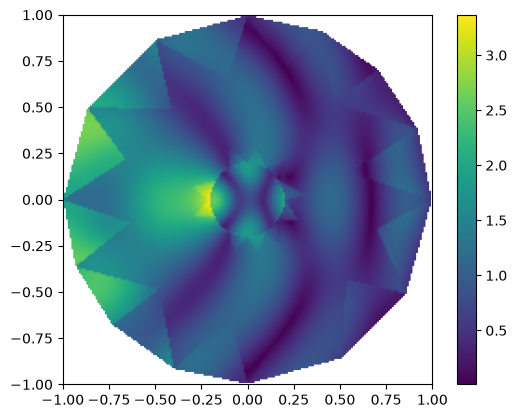

In [35]:
plt.pcolormesh(X, Y, np.abs(Z - Z_exact), shading="gouraud")
plt.axis("square")
plt.colorbar()